In [1]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/noorshabbir/oasis-longitudinal-csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/noorshabbir/oasis-longitudinal-csv/oasis_longitudinal.csv


In [2]:
import pandas as pd

path = "/kaggle/input/datasets/noorshabbir/oasis-longitudinal-csv/oasis_longitudinal.csv"

df = pd.read_csv(path)

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

  Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  

Shape: (373, 15)

Columns:
Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'],
      dtype='object')

Missing values:
Subject ID     0
MRI ID         0
Group          0
Visit      

In [3]:
# Check target distribution
print(df["Group"].value_counts())

# Check categorical values
print("\nM/F:")
print(df["M/F"].value_counts())

print("\nHand:")
print(df["Hand"].value_counts())

print("\nGroup:")
print(df["Group"].value_counts())

Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

M/F:
M/F
F    213
M    160
Name: count, dtype: int64

Hand:
Hand
R    373
Name: count, dtype: int64

Group:
Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64


In [4]:
# Target
y = df["Group"]

# Features
X = df.drop(columns=["Group", "Subject ID", "MRI ID", "Hand"])

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.value_counts())

Features:
Index(['Visit', 'MR Delay', 'M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV',
       'nWBV', 'ASF'],
      dtype='object')

Target:
Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64


In [5]:
# Fill missing values with median
X["SES"] = X["SES"].fillna(X["SES"].median())
X["MMSE"] = X["MMSE"].fillna(X["MMSE"].median())

print(X.isnull().sum())

Visit       0
MR Delay    0
M/F         0
Age         0
EDUC        0
SES         0
MMSE        0
CDR         0
eTIV        0
nWBV        0
ASF         0
dtype: int64


In [6]:
X["M/F"] = X["M/F"].map({"F": 0, "M": 1})

print(X.head())
print("\nData types:")
print(X.dtypes)

   Visit  MR Delay  M/F  Age  EDUC  SES  MMSE  CDR  eTIV   nWBV    ASF
0      1         0    1   87    14  2.0  27.0  0.0  1987  0.696  0.883
1      2       457    1   88    14  2.0  30.0  0.0  2004  0.681  0.876
2      1         0    1   75    12  2.0  23.0  0.5  1678  0.736  1.046
3      2       560    1   76    12  2.0  28.0  0.5  1738  0.713  1.010
4      3      1895    1   80    12  2.0  22.0  0.5  1698  0.701  1.034

Data types:
Visit         int64
MR Delay      int64
M/F           int64
Age           int64
EDUC          int64
SES         float64
MMSE        float64
CDR         float64
eTIV          int64
nWBV        float64
ASF         float64
dtype: object


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (298, 11)
Testing data: (75, 11)


In [8]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

['Nondemented' 'Nondemented' 'Demented' 'Nondemented' 'Demented'
 'Converted' 'Nondemented' 'Demented' 'Demented' 'Nondemented']


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8533333333333334

Classification Report:
              precision    recall  f1-score   support

   Converted       0.40      0.25      0.31         8
    Demented       0.96      0.83      0.89        29
 Nondemented       0.84      1.00      0.92        38

    accuracy                           0.85        75
   macro avg       0.73      0.69      0.70        75
weighted avg       0.84      0.85      0.84        75


Confusion Matrix:
[[ 2  1  5]
 [ 3 24  2]
 [ 0  0 38]]


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9066666666666666

Classification Report:
              precision    recall  f1-score   support

   Converted       0.67      0.25      0.36         8
    Demented       0.97      0.97      0.97        29
 Nondemented       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.84      0.74      0.76        75
weighted avg       0.89      0.91      0.89        75


Confusion Matrix:
[[ 2  1  5]
 [ 1 28  0]
 [ 0  0 38]]


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.8933333333333333

Classification Report:
              precision    recall  f1-score   support

   Converted       0.50      0.25      0.33         8
    Demented       0.96      0.93      0.95        29
 Nondemented       0.88      1.00      0.94        38

    accuracy                           0.89        75
   macro avg       0.78      0.73      0.74        75
weighted avg       0.87      0.89      0.88        75


Confusion Matrix:
[[ 2  1  5]
 [ 2 27  0]
 [ 0  0 38]]


In [12]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(random_state=42))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Accuracy: 0.9066666666666666

Classification Report:
              precision    recall  f1-score   support

   Converted       1.00      0.12      0.22         8
    Demented       0.94      1.00      0.97        29
 Nondemented       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.94      0.71      0.71        75
weighted avg       0.92      0.91      0.87        75


Confusion Matrix:
[[ 1  2  5]
 [ 0 29  0]
 [ 0  0 38]]


In [13]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_balanced_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_balanced_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_balanced_pred))

Accuracy: 0.9066666666666666

Classification Report:
              precision    recall  f1-score   support

   Converted       0.67      0.25      0.36         8
    Demented       0.97      0.97      0.97        29
 Nondemented       0.88      1.00      0.94        38

    accuracy                           0.91        75
   macro avg       0.84      0.74      0.76        75
weighted avg       0.89      0.91      0.89        75


Confusion Matrix:
[[ 2  1  5]
 [ 1 28  0]
 [ 0  0 38]]


In [14]:
print("Total unique subjects:", df["Subject ID"].nunique())

Total unique subjects: 150


In [15]:
from sklearn.model_selection import train_test_split

subjects = df["Subject ID"].unique()

train_subjects, test_subjects = train_test_split(
    subjects,
    test_size=0.2,
    random_state=42
)

train_df = df[df["Subject ID"].isin(train_subjects)].copy()
test_df = df[df["Subject ID"].isin(test_subjects)].copy()

print("Training subjects:", train_df["Subject ID"].nunique())
print("Testing subjects:", test_df["Subject ID"].nunique())

print("\nTraining records:", len(train_df))
print("Testing records:", len(test_df))

Training subjects: 120
Testing subjects: 30

Training records: 297
Testing records: 76


In [16]:
# Target
y_train = train_df["Group"]
y_test = test_df["Group"]

# Features
X_train = train_df.drop(
    columns=["Group", "Subject ID", "MRI ID", "Hand"]
)

X_test = test_df.drop(
    columns=["Group", "Subject ID", "MRI ID", "Hand"]
)

# Encode M/F
X_train["M/F"] = X_train["M/F"].map({"F": 0, "M": 1})
X_test["M/F"] = X_test["M/F"].map({"F": 0, "M": 1})

# Fill missing values using TRAINING medians
X_train["SES"] = X_train["SES"].fillna(X_train["SES"].median())
X_test["SES"] = X_test["SES"].fillna(X_train["SES"].median())

X_train["MMSE"] = X_train["MMSE"].fillna(X_train["MMSE"].median())
X_test["MMSE"] = X_test["MMSE"].fillna(X_train["MMSE"].median())

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

X_train: (297, 11)
X_test: (76, 11)

Training target:
Group
Nondemented    143
Demented       129
Converted       25
Name: count, dtype: int64

Testing target:
Group
Nondemented    47
Demented       17
Converted      12
Name: count, dtype: int64


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_patient = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_patient.fit(X_train, y_train)

rf_patient_pred = rf_patient.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_patient_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_patient_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_patient_pred))

Accuracy: 0.8157894736842105

Classification Report:
              precision    recall  f1-score   support

   Converted       0.00      0.00      0.00        12
    Demented       0.68      1.00      0.81        17
 Nondemented       0.90      0.96      0.93        47

    accuracy                           0.82        76
   macro avg       0.53      0.65      0.58        76
weighted avg       0.71      0.82      0.75        76


Confusion Matrix:
[[ 0  7  5]
 [ 0 17  0]
 [ 1  1 45]]


In [18]:
rf_balanced_patient = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_balanced_patient.fit(X_train, y_train)

rf_balanced_pred = rf_balanced_patient.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_balanced_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_balanced_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_balanced_pred))

Accuracy: 0.8157894736842105

Classification Report:
              precision    recall  f1-score   support

   Converted       0.00      0.00      0.00        12
    Demented       0.68      1.00      0.81        17
 Nondemented       0.90      0.96      0.93        47

    accuracy                           0.82        76
   macro avg       0.53      0.65      0.58        76
weighted avg       0.71      0.82      0.75        76


Confusion Matrix:
[[ 0  7  5]
 [ 0 17  0]
 [ 1  1 45]]


In [19]:
X_train_no_cdr = X_train.drop(columns=["CDR"])
X_test_no_cdr = X_test.drop(columns=["CDR"])

rf_no_cdr = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_no_cdr.fit(X_train_no_cdr, y_train)

pred_no_cdr = rf_no_cdr.predict(X_test_no_cdr)

print("Accuracy:", accuracy_score(y_test, pred_no_cdr))

print("\nClassification Report:")
print(classification_report(y_test, pred_no_cdr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_no_cdr))

Accuracy: 0.5526315789473685

Classification Report:
              precision    recall  f1-score   support

   Converted       0.00      0.00      0.00        12
    Demented       0.42      1.00      0.60        17
 Nondemented       0.71      0.53      0.61        47

    accuracy                           0.55        76
   macro avg       0.38      0.51      0.40        76
weighted avg       0.54      0.55      0.51        76


Confusion Matrix:
[[ 0  2 10]
 [ 0 17  0]
 [ 1 21 25]]


In [20]:
import pandas as pd

importance = pd.Series(
    rf_patient.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

CDR         0.482574
MMSE        0.141383
nWBV        0.059999
ASF         0.055585
Age         0.053343
EDUC        0.053157
MR Delay    0.049281
eTIV        0.045987
M/F         0.025291
SES         0.024046
Visit       0.009353
dtype: float64


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_patient = DecisionTreeClassifier(random_state=42)

dt_patient.fit(X_train, y_train)

dt_pred = dt_patient.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.7368421052631579

Classification Report:
              precision    recall  f1-score   support

   Converted       0.18      0.17      0.17        12
    Demented       0.67      0.71      0.69        17
 Nondemented       0.89      0.89      0.89        47

    accuracy                           0.74        76
   macro avg       0.58      0.59      0.58        76
weighted avg       0.73      0.74      0.73        76


Confusion Matrix:
[[ 2  5  5]
 [ 5 12  0]
 [ 4  1 42]]


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_patient = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_patient.fit(X_train, y_train)

lr_pred = lr_patient.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.868421052631579

Classification Report:
              precision    recall  f1-score   support

   Converted       1.00      0.25      0.40        12
    Demented       0.77      1.00      0.87        17
 Nondemented       0.90      0.98      0.94        47

    accuracy                           0.87        76
   macro avg       0.89      0.74      0.74        76
weighted avg       0.89      0.87      0.84        76


Confusion Matrix:
[[ 3  4  5]
 [ 0 17  0]
 [ 0  1 46]]


In [23]:
from sklearn.svm import SVC

svm_patient = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(random_state=42))
])

svm_patient.fit(X_train, y_train)

svm_pred = svm_patient.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Accuracy: 0.8289473684210527

Classification Report:
              precision    recall  f1-score   support

   Converted       0.50      0.08      0.14        12
    Demented       0.73      0.94      0.82        17
 Nondemented       0.88      0.98      0.93        47

    accuracy                           0.83        76
   macro avg       0.70      0.67      0.63        76
weighted avg       0.79      0.83      0.78        76


Confusion Matrix:
[[ 1  5  6]
 [ 1 16  0]
 [ 0  1 46]]


In [24]:
X_train_no_cdr = X_train.drop(columns=["CDR"])
X_test_no_cdr = X_test.drop(columns=["CDR"])

lr_no_cdr = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_no_cdr.fit(X_train_no_cdr, y_train)

lr_no_cdr_pred = lr_no_cdr.predict(X_test_no_cdr)

print("Accuracy:", accuracy_score(y_test, lr_no_cdr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_no_cdr_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_no_cdr_pred))

Accuracy: 0.6710526315789473

Classification Report:
              precision    recall  f1-score   support

   Converted       0.00      0.00      0.00        12
    Demented       0.53      1.00      0.69        17
 Nondemented       0.77      0.72      0.75        47

    accuracy                           0.67        76
   macro avg       0.43      0.57      0.48        76
weighted avg       0.60      0.67      0.62        76


Confusion Matrix:
[[ 0  2 10]
 [ 0 17  0]
 [ 0 13 34]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


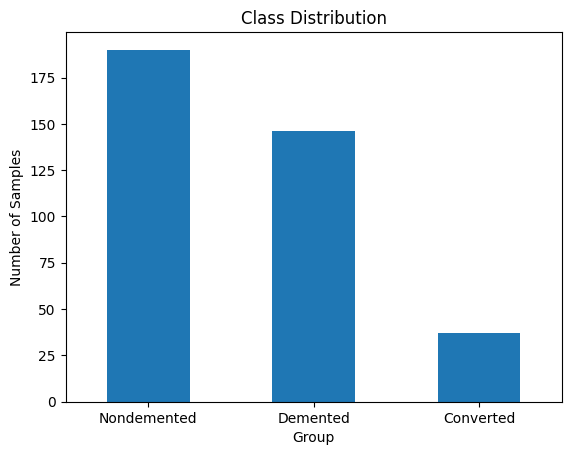

In [25]:
import matplotlib.pyplot as plt

df["Group"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Group")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

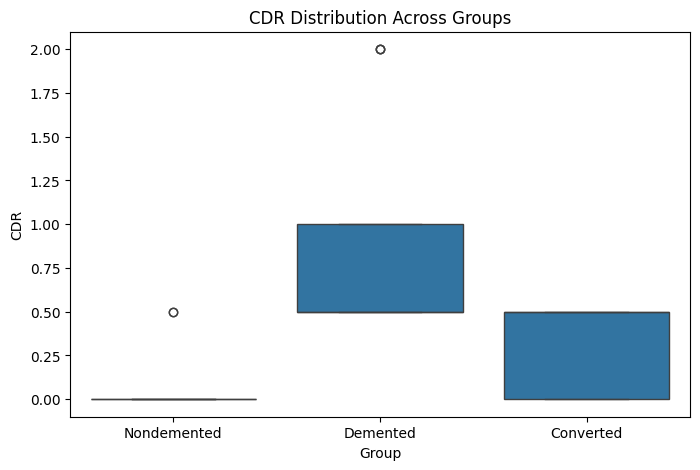

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Group", y="CDR")

plt.title("CDR Distribution Across Groups")
plt.xlabel("Group")
plt.ylabel("CDR")
plt.show()

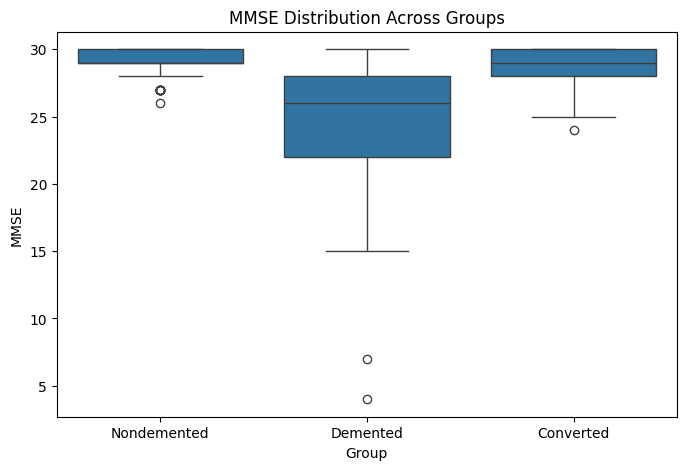

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Group", y="MMSE")

plt.title("MMSE Distribution Across Groups")
plt.xlabel("Group")
plt.ylabel("MMSE")
plt.show()

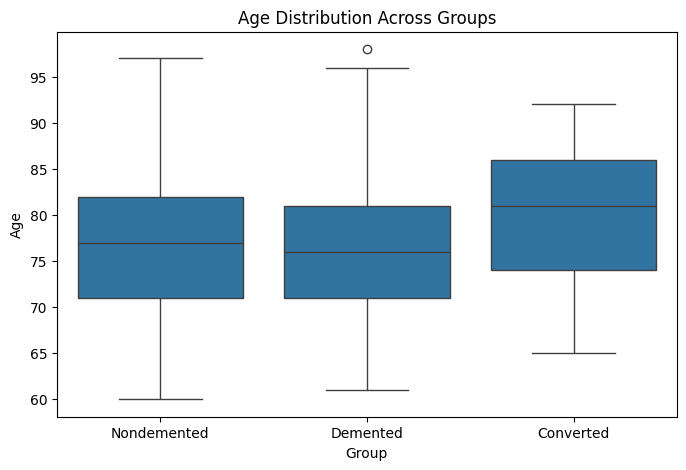

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Group", y="Age")

plt.title("Age Distribution Across Groups")
plt.xlabel("Group")
plt.ylabel("Age")
plt.show()

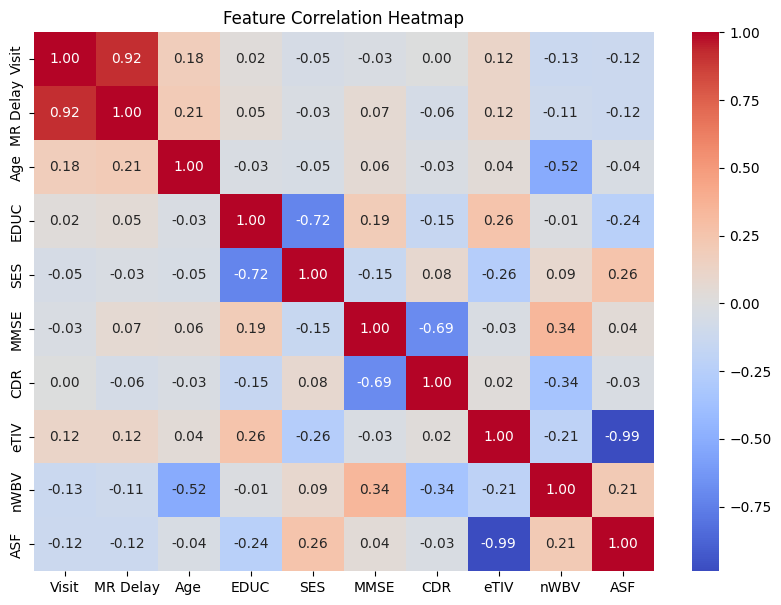

In [29]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [30]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Original dataframe se features
X_cv = df.drop(columns=["Group", "Subject ID", "MRI ID", "Hand"]).copy()
y_cv = df["Group"]
groups = df["Subject ID"]

# Encode gender
X_cv["M/F"] = X_cv["M/F"].map({"F": 0, "M": 1})

# Missing values
X_cv["SES"] = X_cv["SES"].fillna(X_cv["SES"].median())
X_cv["MMSE"] = X_cv["MMSE"].fillna(X_cv["MMSE"].median())

# Model
lr_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Patient-wise 5-fold CV
group_kfold = GroupKFold(n_splits=5)

scores = cross_val_score(
    lr_cv,
    X_cv,
    y_cv,
    cv=group_kfold,
    groups=groups,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold accuracies: [0.90666667 0.93333333 0.90666667 0.89189189 0.89189189]
Mean accuracy: 0.9060900900900901
Standard deviation: 0.015139596082184428


In [31]:
from sklearn.model_selection import cross_val_score

f1_scores = cross_val_score(
    lr_cv,
    X_cv,
    y_cv,
    cv=group_kfold,
    groups=groups,
    scoring="f1_macro"
)

print("Fold Macro F1:", f1_scores)
print("Mean Macro F1:", f1_scores.mean())
print("Standard deviation:", f1_scores.std())

Fold Macro F1: [0.75567063 0.82430022 0.76444444 0.74401154 0.62311762]
Mean Macro F1: 0.7423088916038093
Standard deviation: 0.06572754911263287


In [32]:
# Fit the final Logistic Regression model
lr_cv.fit(X_cv, y_cv)

# Get the classifier from the pipeline
classifier = lr_cv.named_steps["classifier"]

# Get feature names
feature_names = X_cv.columns

# Create coefficient table
coef_df = pd.DataFrame(
    classifier.coef_,
    columns=feature_names,
    index=classifier.classes_
)

print(coef_df)

               Visit  MR Delay       M/F       Age      EDUC       SES  \
Converted   -0.01261  0.158812 -0.163296  0.354445 -0.134325 -0.689902   
Demented    -0.46971 -0.323877  0.617477 -0.526100 -0.331867  0.135765   
Nondemented  0.48232  0.165065 -0.454181  0.171655  0.466192  0.554137   

                 MMSE       CDR      eTIV      nWBV       ASF  
Converted    0.460518  0.134110 -0.671293  0.065058 -0.444876  
Demented    -1.129646  2.904657 -0.028833 -0.367812  0.288673  
Nondemented  0.669127 -3.038767  0.700126  0.302754  0.156204  


In [33]:
X_cv_no_cdr = X_cv.drop(columns=["CDR"])

lr_no_cdr_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

accuracy_no_cdr = cross_val_score(
    lr_no_cdr_cv,
    X_cv_no_cdr,
    y_cv,
    cv=group_kfold,
    groups=groups,
    scoring="accuracy"
)

f1_no_cdr = cross_val_score(
    lr_no_cdr_cv,
    X_cv_no_cdr,
    y_cv,
    cv=group_kfold,
    groups=groups,
    scoring="f1_macro"
)

print("Accuracy folds:", accuracy_no_cdr)
print("Mean Accuracy:", accuracy_no_cdr.mean())
print("Accuracy Std:", accuracy_no_cdr.std())

print("\nMacro F1 folds:", f1_no_cdr)
print("Mean Macro F1:", f1_no_cdr.mean())
print("Macro F1 Std:", f1_no_cdr.std())

Accuracy folds: [0.73333333 0.70666667 0.77333333 0.75675676 0.74324324]
Mean Accuracy: 0.7426666666666666
Accuracy Std: 0.022460715192758527

Macro F1 folds: [0.52792793 0.49659443 0.60862785 0.54029545 0.5154553 ]
Mean Macro F1: 0.5377801922281151
Macro F1 Std: 0.03825559320095189


In [34]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        0.7368,
        0.8158,
        0.8684,
        0.8289
    ],
    "Macro F1": [
        0.58,
        0.58,
        0.74,
        0.63
    ],
    "Converted Recall": [
        0.17,
        0.00,
        0.25,
        0.08
    ]
})

results

,Model,Accuracy,Macro F1,Converted Recall
0,Decision Tree,0.7368,0.58,0.17
1,Random Forest,0.8158,0.58,0.00
2,Logistic Regression,0.8684,0.74,0.25
3,SVM,0.8289,0.63,0.08


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Final Logistic Regression model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
final_model.fit(X_train, y_train)

# Make predictions
final_pred = final_model.predict(X_test)

# Accuracy
print("Final Model Accuracy:", accuracy_score(y_test, final_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, final_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Model Accuracy: 0.868421052631579

Classification Report:
              precision    recall  f1-score   support

   Converted       1.00      0.25      0.40        12
    Demented       0.77      1.00      0.87        17
 Nondemented       0.90      0.98      0.94        47

    accuracy                           0.87        76
   macro avg       0.89      0.74      0.74        76
weighted avg       0.89      0.87      0.84        76


Confusion Matrix:
[[ 3  4  5]
 [ 0 17  0]
 [ 0  1 46]]


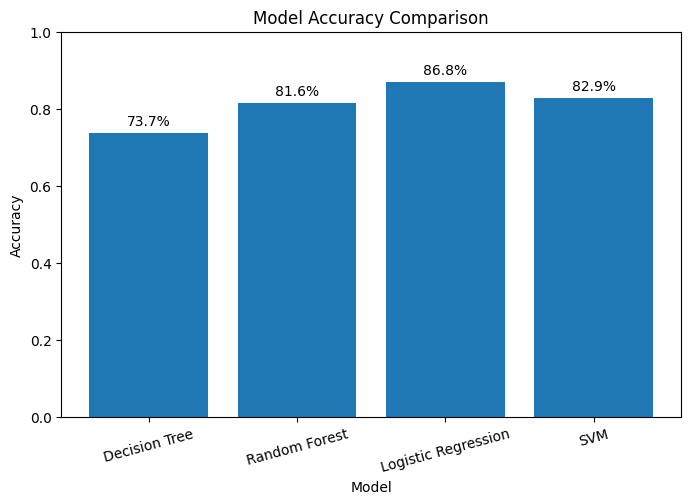

In [36]:
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest", "Logistic Regression", "SVM"]
accuracies = [0.7368, 0.8158, 0.8684, 0.8289]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy:.1%}", ha="center")

plt.xticks(rotation=15)
plt.show()

     Feature  Importance
7        CDR    0.482574
6       MMSE    0.141383
9       nWBV    0.059999
10       ASF    0.055585
3        Age    0.053343
4       EDUC    0.053157
1   MR Delay    0.049281
8       eTIV    0.045987
2        M/F    0.025291
5        SES    0.024046
0      Visit    0.009353


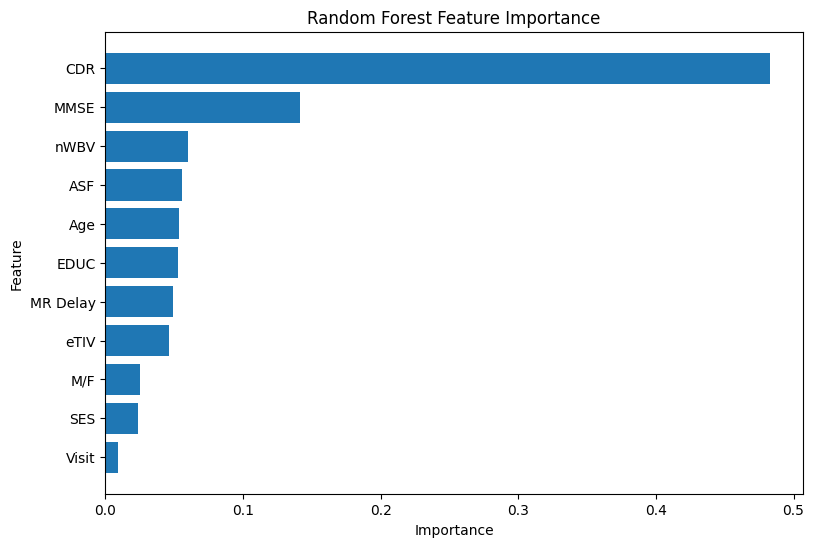

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the patient-wise Random Forest
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_patient.feature_importances_
})

# Sort from highest to lowest
importance = importance.sort_values("Importance", ascending=False)

print(importance)

# Plot
plt.figure(figsize=(9, 6))
plt.barh(importance["Feature"], importance["Importance"])

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.show()

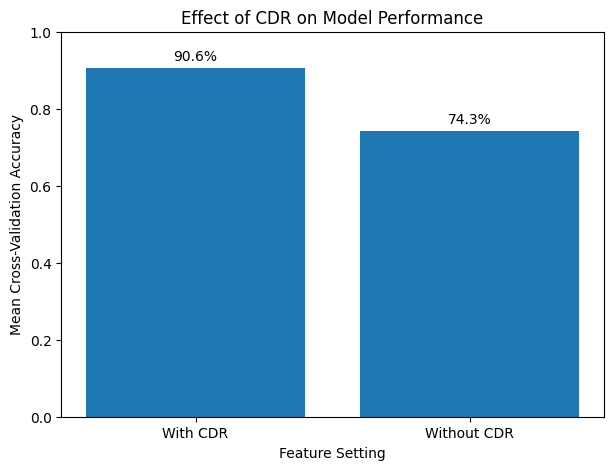

In [38]:
import matplotlib.pyplot as plt

models = ["With CDR", "Without CDR"]
accuracies = [0.9061, 0.7427]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.title("Effect of CDR on Model Performance")
plt.xlabel("Feature Setting")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.ylim(0, 1)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy:.1%}", ha="center")

plt.show()

In [39]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        0.7368,
        0.8158,
        0.8684,
        0.8289
    ],
    "Macro F1": [
        0.58,
        0.58,
        0.74,
        0.63
    ],
    "Converted Recall": [
        0.1667,
        0.00,
        0.25,
        0.0833
    ]
})

results["Accuracy"] = (results["Accuracy"] * 100).round(2)
results["Macro F1"] = results["Macro F1"].round(2)
results["Converted Recall"] = (results["Converted Recall"] * 100).round(2)

print(results)

                 Model  Accuracy  Macro F1  Converted Recall
0        Decision Tree     73.68      0.58             16.67
1        Random Forest     81.58      0.58              0.00
2  Logistic Regression     86.84      0.74             25.00
3                  SVM     82.89      0.63              8.33


In [40]:
import joblib

joblib.dump(final_model, "cognitive_status_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [41]:
import joblib

# Load the saved model
loaded_model = joblib.load("cognitive_status_model.pkl")

# Test the loaded model
loaded_pred = loaded_model.predict(X_test)

print("Loaded model accuracy:", accuracy_score(y_test, loaded_pred))

Loaded model accuracy: 0.868421052631579


In [42]:
from IPython.display import FileLink

FileLink("cognitive_status_model.pkl")

/kaggle/working/cognitive_status_model.pkl